In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../results/figures")

file_table = pd.read_csv(PROCESSED_DATA_DIR / "file_table.csv")
file_table["file_path"] = file_table["file_path"].apply(Path)

file_table.head()

,file_name,file_path,study,group,subject_id,subject_number,trial
0,GaCo01_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo01,1,1
1,GaCo02_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo02,2,1
2,GaCo02_02.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo02,2,2
3,GaCo03_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo03,3,1
4,GaCo03_02.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo03,3,2


In [3]:
file_table.shape

(306, 7)

In [4]:
def load_gait_signal(file_path):
    df = pd.read_csv(file_path, sep=r"\s+", header=None)
    
    columns = (
        ["time"]
        + [f"left_sensor_{i}" for i in range(1, 9)]
        + [f"right_sensor_{i}" for i in range(1, 9)]
        + ["left_total_force", "right_total_force"]
    )
    
    if df.shape[1] != len(columns):
        raise ValueError(
            f"{Path(file_path).name} has {df.shape[1]} columns, "
            f"but expected {len(columns)}"
        )
    
    df.columns = columns
    return df

In [5]:
def add_foot_contact_columns(df, threshold=20):
    df = df.copy()
    
    df["left_contact"] = df["left_total_force"] > threshold
    df["right_contact"] = df["right_total_force"] > threshold
    
    return df

In [6]:
def detect_contact_events(df, contact_column):
    contact = df[contact_column].astype(bool)
    
    contact_start = contact & ~contact.shift(1, fill_value=False)
    contact_end = contact & ~contact.shift(-1, fill_value=False)
    
    start_indices = df.index[contact_start].to_list()
    end_indices = df.index[contact_end].to_list()
    
    events = []
    
    for start_idx, end_idx in zip(start_indices, end_indices):
        start_time = df.loc[start_idx, "time"]
        end_time = df.loc[end_idx, "time"]
        duration = end_time - start_time
        
        events.append({
            "start_idx": start_idx,
            "end_idx": end_idx,
            "start_time": start_time,
            "end_time": end_time,
            "duration": duration
        })
    
    return pd.DataFrame(events)

In [7]:
def filter_contact_events(events, min_duration=0.2, max_duration=2.0):
    if events.empty:
        return events
    
    return events[
        (events["duration"] >= min_duration) &
        (events["duration"] <= max_duration)
    ].reset_index(drop=True)

In [8]:
def safe_mean(series):
    return series.mean() if len(series) > 0 else np.nan

def safe_std(series):
    return series.std() if len(series) > 1 else np.nan

def safe_cv(series):
    mean_value = safe_mean(series)
    std_value = safe_std(series)
    
    if pd.isna(mean_value) or mean_value == 0:
        return np.nan
    
    return std_value / mean_value

In [9]:
def extract_contact_features(df, threshold=20):
    df = add_foot_contact_columns(df, threshold=threshold)
    
    left_events = detect_contact_events(df, "left_contact")
    right_events = detect_contact_events(df, "right_contact")
    
    left_events_clean = filter_contact_events(left_events)
    right_events_clean = filter_contact_events(right_events)
    
    recording_duration = df["time"].max() - df["time"].min()
    
    features = {
        "recording_duration_sec": recording_duration,
        
        "left_contact_count": len(left_events_clean),
        "right_contact_count": len(right_events_clean),
        
        "left_contacts_per_sec": len(left_events_clean) / recording_duration,
        "right_contacts_per_sec": len(right_events_clean) / recording_duration,
        
        "mean_left_contact_duration": safe_mean(left_events_clean["duration"]),
        "mean_right_contact_duration": safe_mean(right_events_clean["duration"]),
        
        "std_left_contact_duration": safe_std(left_events_clean["duration"]),
        "std_right_contact_duration": safe_std(right_events_clean["duration"]),
        
        "cv_left_contact_duration": safe_cv(left_events_clean["duration"]),
        "cv_right_contact_duration": safe_cv(right_events_clean["duration"]),
        
        "contact_count_difference": abs(
            len(left_events_clean) - len(right_events_clean)
        ),
        
        "mean_contact_duration_difference": abs(
            safe_mean(left_events_clean["duration"]) -
            safe_mean(right_events_clean["duration"])
        ),
        
        "cv_contact_duration_difference": abs(
            safe_cv(left_events_clean["duration"]) -
            safe_cv(right_events_clean["duration"])
        ),
    }
    
    return features

In [10]:
test_file = file_table["file_path"].iloc[0]

test_df = load_gait_signal(test_file)
test_features = extract_contact_features(test_df, threshold=20)

test_features

{'recording_duration_sec': 121.1715,
 'left_contact_count': 94,
 'right_contact_count': 98,
 'left_contacts_per_sec': 0.7757599765621455,
 'right_contacts_per_sec': 0.8087710393945772,
 'mean_left_contact_duration': 0.7777106382978712,
 'mean_right_contact_duration': 0.784537755102041,
 'std_left_contact_duration': 0.07087804529587814,
 'std_right_contact_duration': 0.12696223118504868,
 'cv_left_contact_duration': 0.09113678250692916,
 'cv_right_contact_duration': 0.16183061982598315,
 'contact_count_difference': 4,
 'mean_contact_duration_difference': 0.006827116804169808,
 'cv_contact_duration_difference': 0.07069383731905399}

In [11]:
all_features = []

for idx, row in file_table.iterrows():
    file_path = Path(row["file_path"])
    
    try:
        df = load_gait_signal(file_path)
        features = extract_contact_features(df, threshold=20)
        
        features["file_name"] = row["file_name"]
        features["file_path"] = row["file_path"]
        features["study"] = row["study"]
        features["group"] = row["group"]
        features["subject_id"] = row["subject_id"]
        features["trial"] = row["trial"]
        
        all_features.append(features)
        
    except Exception as e:
        print(f"Error processing {row['file_name']}: {e}")

In [12]:
contact_feature_table = pd.DataFrame(all_features)

contact_feature_table.head()

,recording_duration_sec,left_contact_count,right_contact_count,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,std_left_contact_duration,std_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,contact_count_difference,mean_contact_duration_difference,cv_contact_duration_difference,file_name,file_path,study,group,subject_id,trial
0,121.1715,94,98,0.775760,0.808771,0.777711,0.784538,0.070878,0.126962,0.091137,0.161831,4,0.006827,0.070694,GaCo01_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo01,1
1,121.1715,102,108,0.841782,0.891299,0.702500,0.715782,0.053232,0.111449,0.075774,0.155703,6,0.013282,0.079928,GaCo02_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo02,1
2,121.1715,114,115,0.940815,0.949068,0.680303,0.674213,0.068307,0.089574,0.100407,0.132857,1,0.006090,0.032450,GaCo02_02.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo02,2
3,121.1715,94,97,0.775760,0.800518,0.857168,0.806341,0.106978,0.120583,0.124804,0.149544,3,0.050827,0.024739,GaCo03_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo03,1
4,121.1715,109,108,0.899551,0.891299,0.724902,0.716803,0.080154,0.053564,0.110572,0.074727,1,0.008099,0.035845,GaCo03_02.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo03,2


In [13]:
contact_feature_table.shape

(306, 20)

In [14]:
id_cols = [
    "file_name",
    "study",
    "group",
    "subject_id",
    "trial",
    "file_path"
]

feature_cols = [
    col for col in contact_feature_table.columns 
    if col not in id_cols
]

contact_feature_table = contact_feature_table[id_cols + feature_cols]

contact_feature_table.head()

,file_name,study,group,subject_id,trial,file_path,recording_duration_sec,left_contact_count,right_contact_count,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,std_left_contact_duration,std_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,contact_count_difference,mean_contact_duration_difference,cv_contact_duration_difference
0,GaCo01_01.txt,Ga,Control,GaCo01,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,94,98,0.775760,0.808771,0.777711,0.784538,0.070878,0.126962,0.091137,0.161831,4,0.006827,0.070694
1,GaCo02_01.txt,Ga,Control,GaCo02,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,102,108,0.841782,0.891299,0.702500,0.715782,0.053232,0.111449,0.075774,0.155703,6,0.013282,0.079928
2,GaCo02_02.txt,Ga,Control,GaCo02,2,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,114,115,0.940815,0.949068,0.680303,0.674213,0.068307,0.089574,0.100407,0.132857,1,0.006090,0.032450
3,GaCo03_01.txt,Ga,Control,GaCo03,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,94,97,0.775760,0.800518,0.857168,0.806341,0.106978,0.120583,0.124804,0.149544,3,0.050827,0.024739
4,GaCo03_02.txt,Ga,Control,GaCo03,2,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,109,108,0.899551,0.891299,0.724902,0.716803,0.080154,0.053564,0.110572,0.074727,1,0.008099,0.035845


In [15]:
contact_feature_table.isna().sum()

file_name                           0
study                               0
group                               0
subject_id                          0
trial                               0
file_path                           0
recording_duration_sec              0
left_contact_count                  0
right_contact_count                 0
left_contacts_per_sec               0
right_contacts_per_sec              0
mean_left_contact_duration          0
mean_right_contact_duration         0
std_left_contact_duration           0
std_right_contact_duration          0
cv_left_contact_duration            0
cv_right_contact_duration           0
contact_count_difference            0
mean_contact_duration_difference    0
cv_contact_duration_difference      0
dtype: int64

In [16]:
contact_feature_table["group"].value_counts()

group
Parkinson    214
Control       92
Name: count, dtype: int64

In [17]:
pd.crosstab(
    contact_feature_table["study"],
    contact_feature_table["group"]
)

group,Control,Parkinson
study,,
Ga,38,75
Ju,25,104
Si,29,35


In [18]:
contact_feature_table.describe()

,trial,recording_duration_sec,left_contact_count,right_contact_count,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,std_left_contact_duration,std_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,contact_count_difference,mean_contact_duration_difference,cv_contact_duration_difference
count,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000
mean,2.758170,108.399068,97.124183,97.352941,0.902542,0.904504,0.726372,0.726285,0.095522,0.096179,0.132781,0.132856,1.718954,0.021382,0.052496
std,2.785268,25.828004,22.422419,22.701042,0.099218,0.102933,0.108083,0.100601,0.042686,0.042061,0.061390,0.057670,2.335633,0.019996,0.051690
min,1.000000,40.327200,29.000000,30.000000,0.459026,0.355095,0.563144,0.559813,0.016964,0.014715,0.025382,0.020481,0.000000,0.000024,0.000135
25%,1.000000,91.853600,84.000000,85.000000,0.858288,0.858288,0.663984,0.664603,0.061071,0.062020,0.083868,0.087386,0.000000,0.006708,0.017253
50%,1.000000,121.171500,102.000000,102.500000,0.907804,0.914949,0.703861,0.709405,0.092552,0.091743,0.124928,0.124229,1.000000,0.016974,0.035782
75%,3.000000,121.171500,112.000000,113.000000,0.965574,0.965574,0.757201,0.765839,0.123871,0.127826,0.164920,0.172830,2.000000,0.028998,0.068983
max,10.000000,263.631500,168.000000,164.000000,1.136940,1.115076,1.586868,1.423932,0.253151,0.255350,0.401539,0.326307,22.000000,0.162936,0.264734


In [19]:
contact_feature_table[
    contact_feature_table["left_contact_count"] < 10
][["file_name", "study", "group", "recording_duration_sec", "left_contact_count", "right_contact_count"]]

,file_name,study,group,recording_duration_sec,left_contact_count,right_contact_count


In [20]:
contact_feature_table[
    contact_feature_table["mean_left_contact_duration"] > 2
][["file_name", "study", "group", "mean_left_contact_duration", "mean_right_contact_duration"]]

,file_name,study,group,mean_left_contact_duration,mean_right_contact_duration


In [21]:
contact_feature_table.to_csv(
    PROCESSED_DATA_DIR / "contact_feature_table.csv",
    index=False
)

In [22]:
contact_feature_table.groupby("group")[
    [
        "left_contacts_per_sec",
        "right_contacts_per_sec",
        "mean_left_contact_duration",
        "mean_right_contact_duration",
        "cv_left_contact_duration",
        "cv_right_contact_duration",
        "contact_count_difference",
        "mean_contact_duration_difference"
    ]
].mean()

,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,contact_count_difference,mean_contact_duration_difference
group,,,,,,,,
Control,0.903092,0.904740,0.702003,0.700897,0.126378,0.123483,1.467391,0.014245
Parkinson,0.902305,0.904403,0.736848,0.737199,0.135534,0.136886,1.827103,0.024451


In [23]:
contact_feature_table.groupby(["study", "group"])[
    [
        "left_contacts_per_sec",
        "right_contacts_per_sec",
        "mean_left_contact_duration",
        "mean_right_contact_duration"
    ]
].mean()

left_contacts_per_sec  right_contacts_per_sec  \
study group                                                      
Ga    Control                 0.884450                0.888753   
      Parkinson               0.880075                0.885027   
Ju    Control                 0.909785                0.907989   
      Parkinson               0.928865                0.929531   
Si    Control                 0.921749                0.922887   
      Parkinson               0.871020                0.871256   

                 mean_left_contact_duration  mean_right_contact_duration  
study group                                                               
Ga    Control                      0.700725                     0.700304  
      Parkinson                    0.770925                     0.766560  
Ju    Control                      0.704595                     0.704621  
      Parkinson                    0.713083                     0.713215  
Si    Control                      0.701443                     0.698464  
      Parkinson                    0.734444                     0.745549

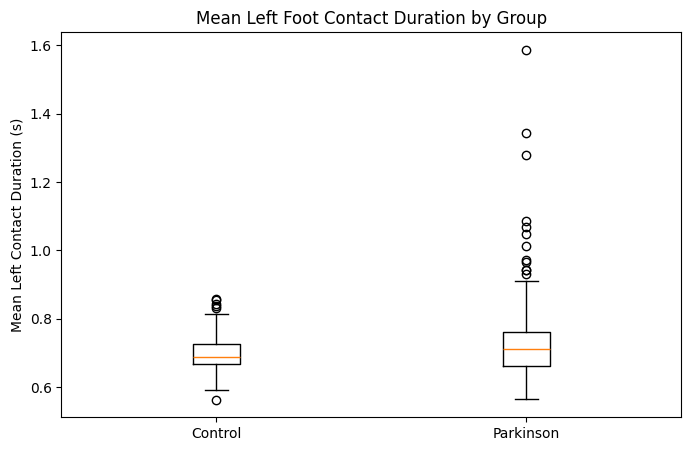

In [24]:
plt.figure(figsize=(8, 5))

groups = [
    contact_feature_table[contact_feature_table["group"] == "Control"]["mean_left_contact_duration"],
    contact_feature_table[contact_feature_table["group"] == "Parkinson"]["mean_left_contact_duration"]
]

plt.boxplot(groups, labels=["Control", "Parkinson"])
plt.ylabel("Mean Left Contact Duration (s)")
plt.title("Mean Left Foot Contact Duration by Group")
plt.show()

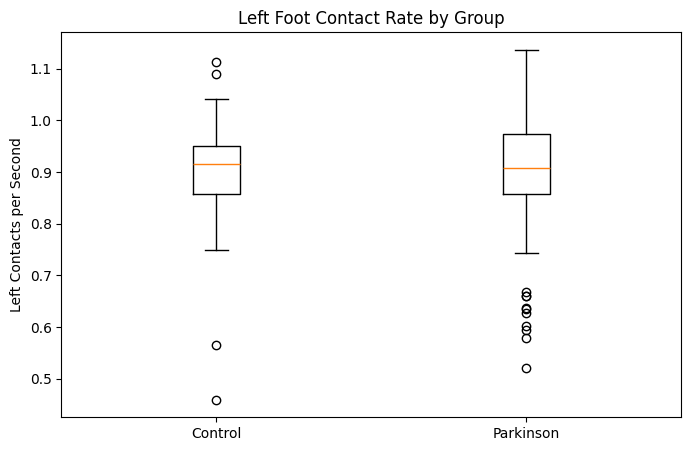

In [25]:
plt.figure(figsize=(8, 5))

groups = [
    contact_feature_table[contact_feature_table["group"] == "Control"]["left_contacts_per_sec"],
    contact_feature_table[contact_feature_table["group"] == "Parkinson"]["left_contacts_per_sec"]
]

plt.boxplot(groups, labels=["Control", "Parkinson"])
plt.ylabel("Left Contacts per Second")
plt.title("Left Foot Contact Rate by Group")
plt.show()

## Milestone 3 conclusion

The foot-contact detection pipeline was applied to all 306 gait signal files.  
For each recording, basic contact-based features were extracted, including contact count, contact rate, mean contact duration, contact duration variability, and left-right difference measures.

The resulting feature table contains one row per recording and will be used for group-level exploratory analysis in the next milestone.

At this stage, the features should be interpreted as preliminary because they depend on a simple fixed-threshold contact detection method. Later analysis should include additional quality checks and possibly compare fixed-threshold detection with an adaptive threshold method.